CYBERBULLYING DETECTION USING LOGISTIC REGRESSION

Dataset Shape: (577, 2)

Dataset Columns:
['text', 'label']

Text Column : text
Label Column: label

Dataset After Cleaning: (577, 2)

Class Distribution:
label
1    291
0    286
Name: count, dtype: int64


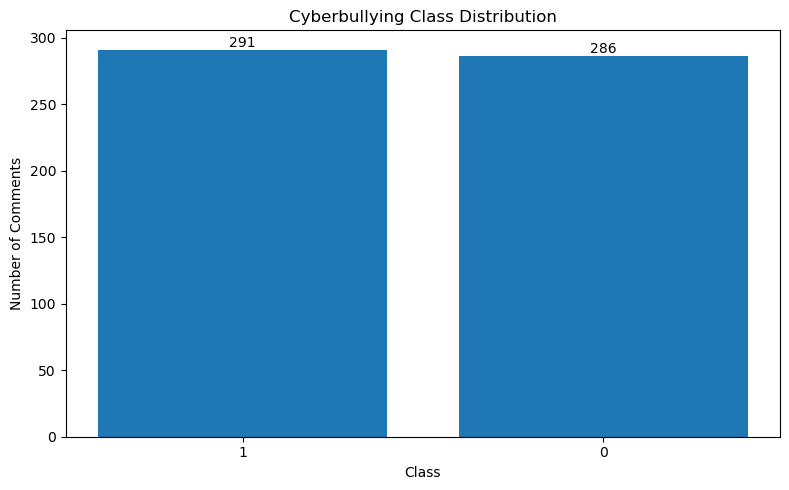

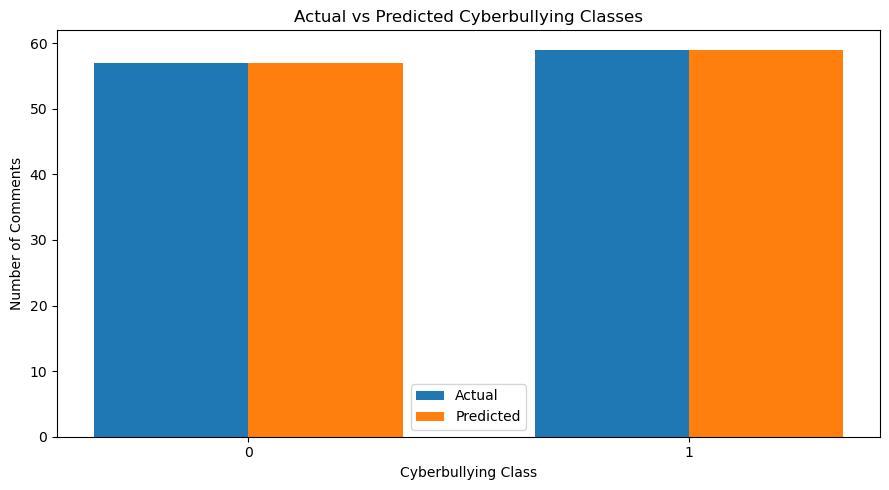

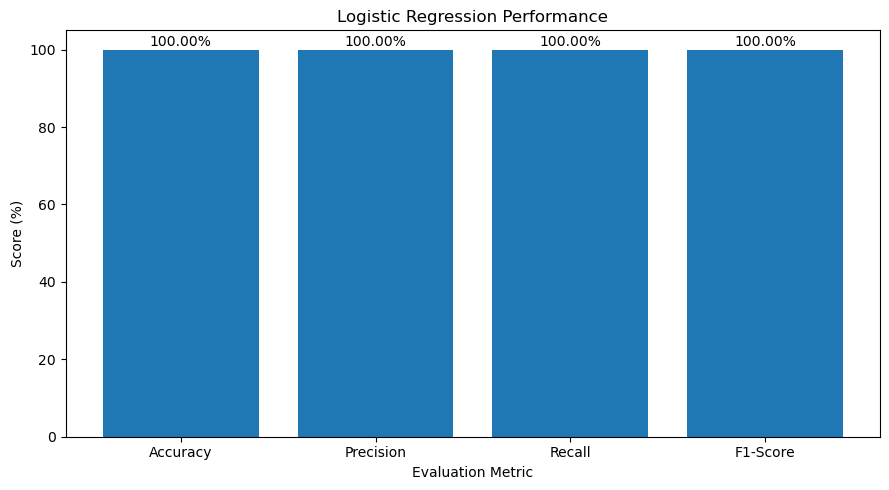

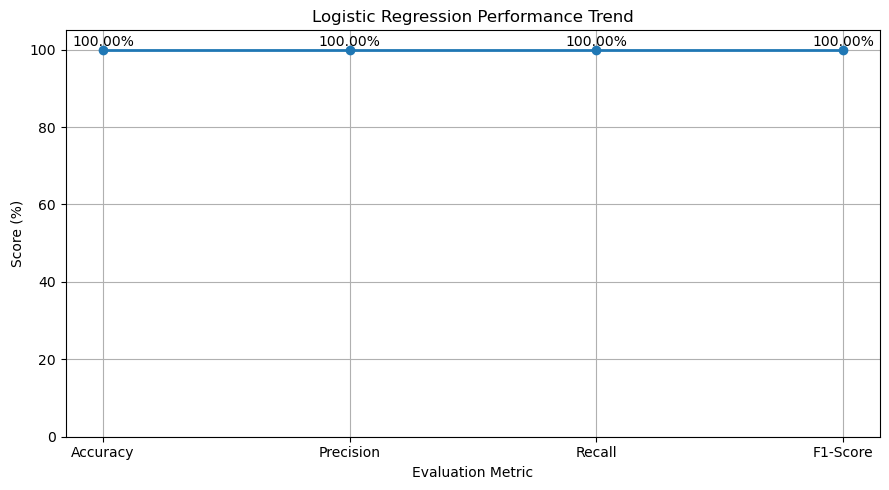

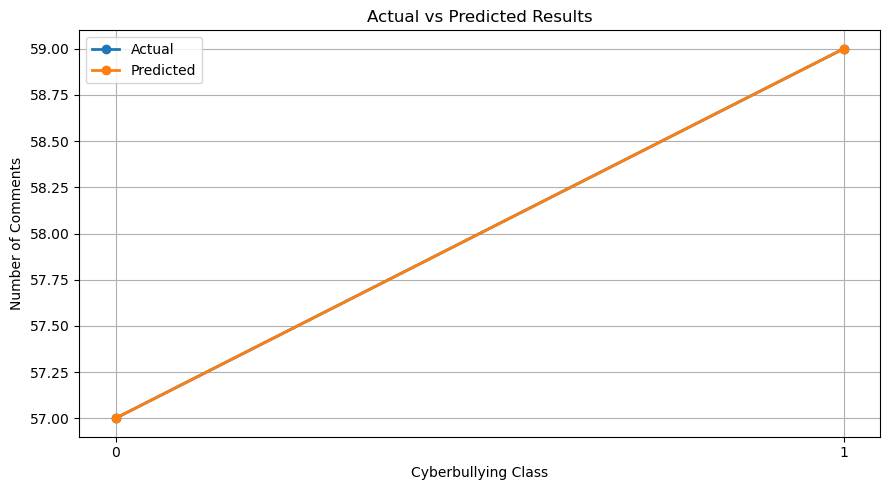

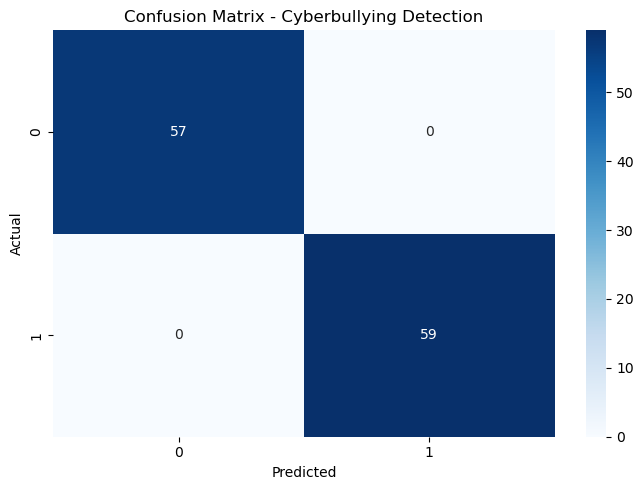

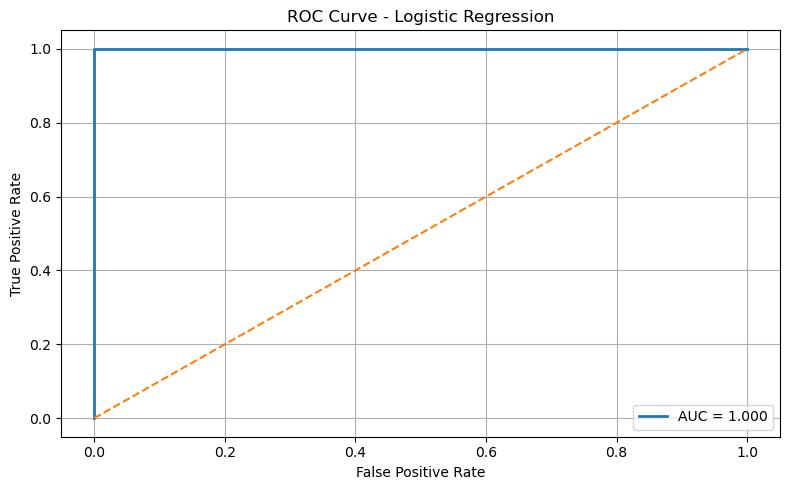

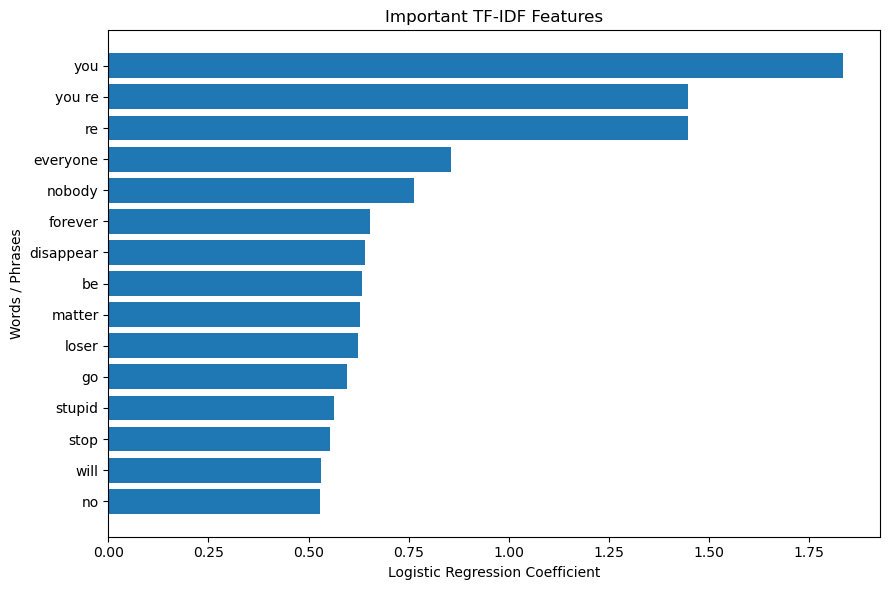

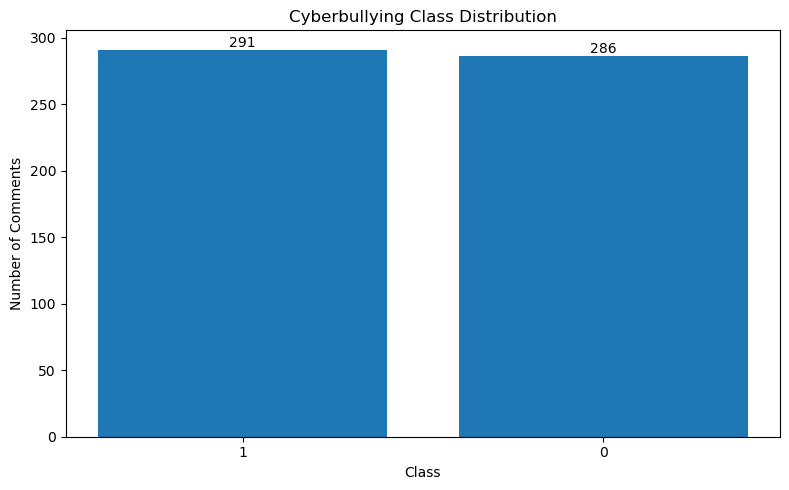


Training Samples: 461
Testing Samples : 116

Training Logistic Regression Model...

Best Parameters:
{'model__C': 0.5}

Best Cross-Validation Score:
100.00%

MODEL PERFORMANCE

Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1-Score : 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        59

    accuracy                           1.00       116
   macro avg       1.00      1.00      1.00       116
weighted avg       1.00      1.00      1.00       116



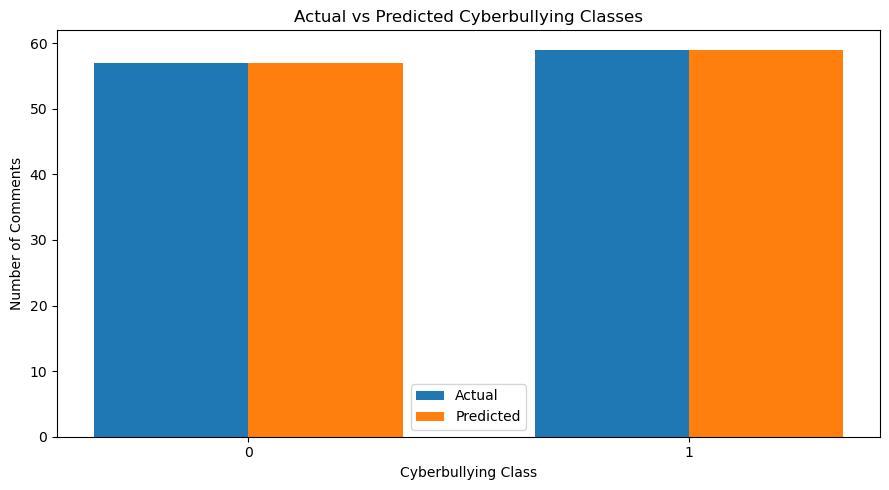

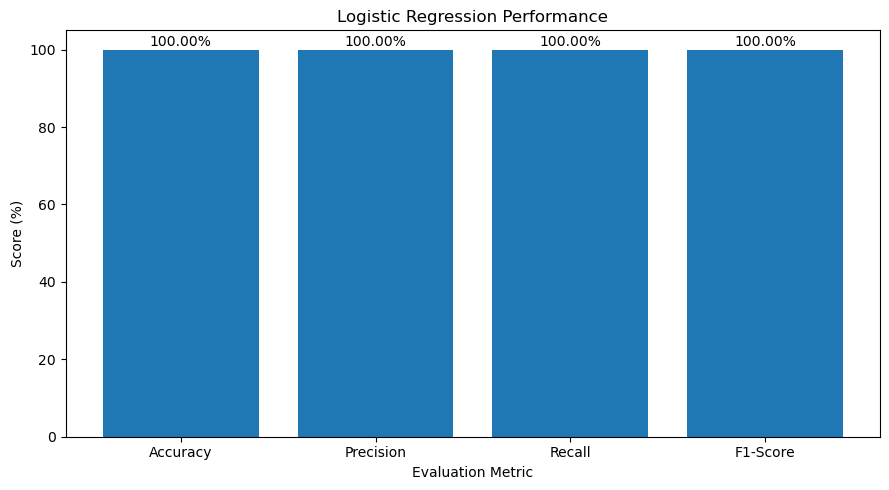

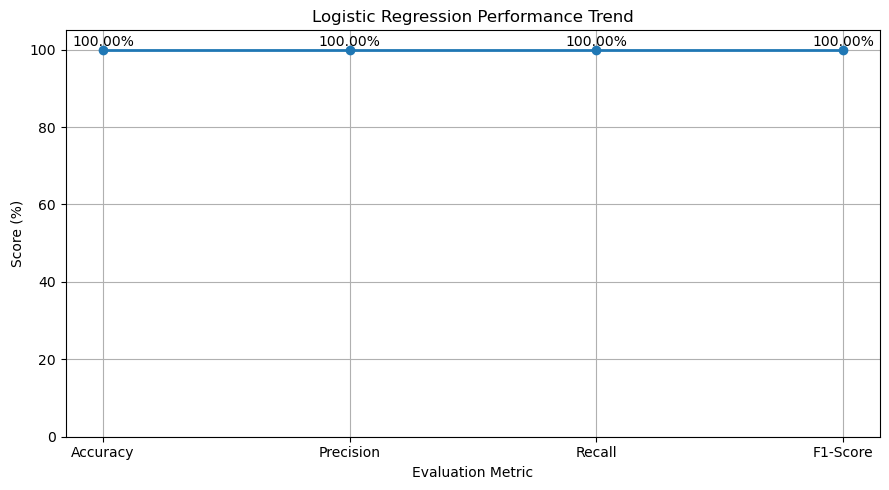

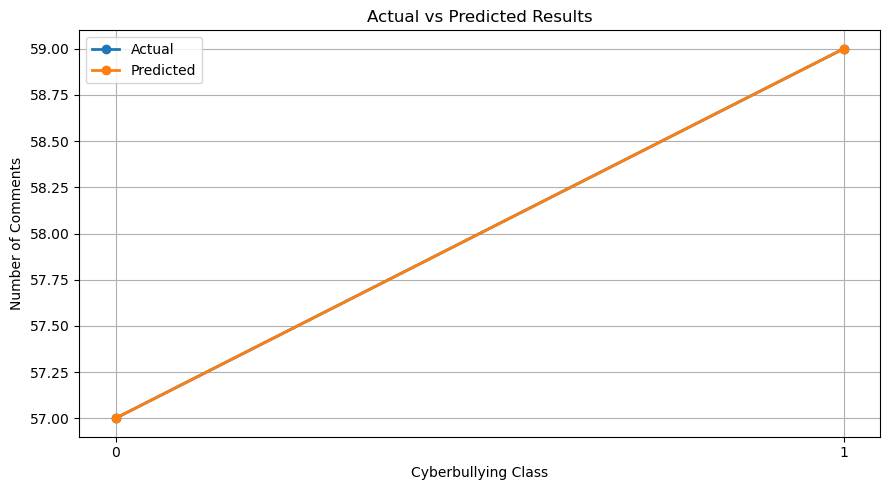

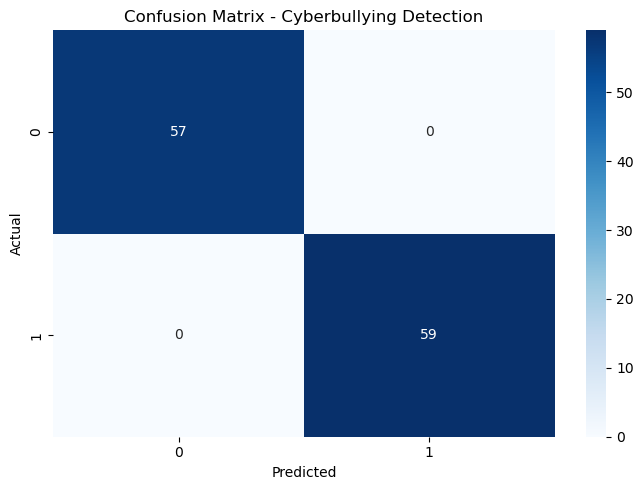


ROC-AUC: 1.000


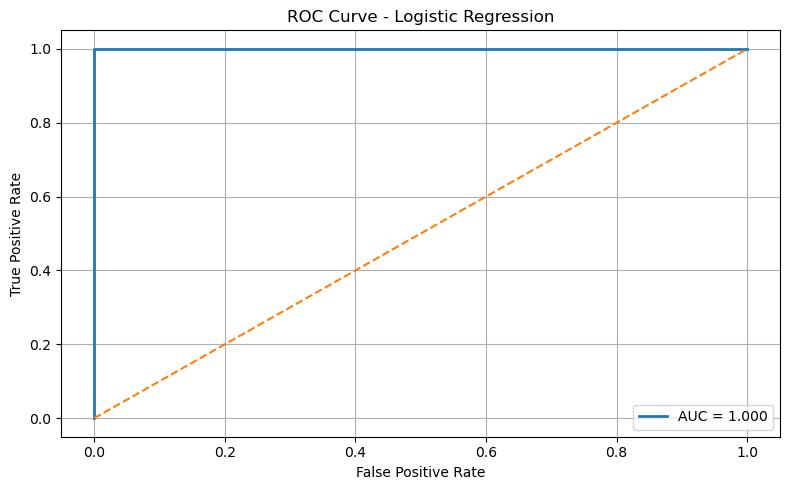

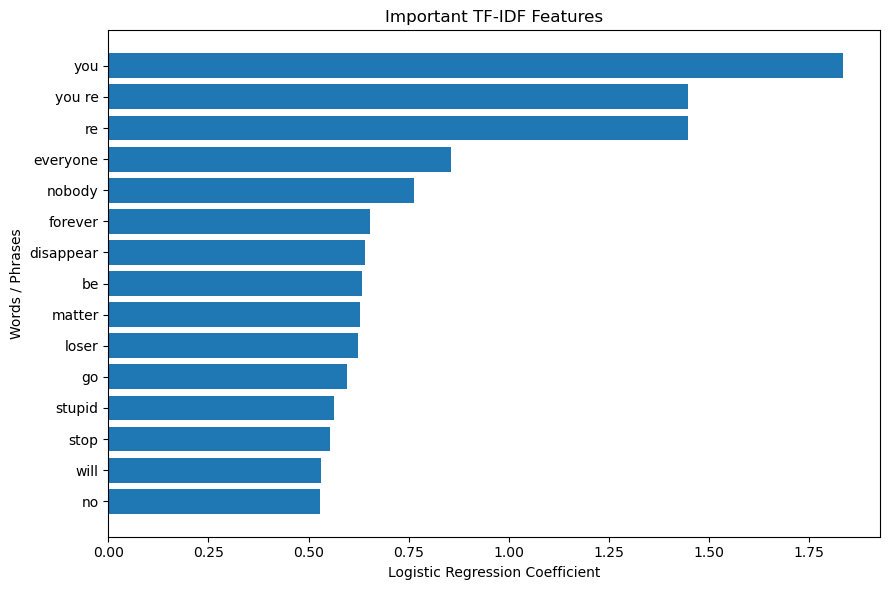


CUSTOM CYBERBULLYING TEST

Comment: You are a wonderful person
Prediction: 0

Comment: Nobody likes you, go away
Prediction: 1

Comment: You did a great job today
Prediction: 0

Comment: You are stupid and useless
Prediction: 1

PROJECT COMPLETED SUCCESSFULLY

Final Accuracy:
100.00%

Generated Graphs:
1. class_distribution.png
2. actual_vs_predicted_bar.png
3. model_performance_bar.png
4. model_performance_line.png
5. actual_vs_predicted_line.png
6. confusion_matrix.png
7. roc_curve.png
8. top_tfidf_features.png

All graphs use your existing dataset.


In [7]:
# ============================================================
# CYBERBULLYING DETECTION USING LOGISTIC REGRESSION
# Complete ML Mini Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Force Jupyter Notebook to display Matplotlib plots inline
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("Documents/cyberbullying.csv")

print("=" * 60)
print("CYBERBULLYING DETECTION USING LOGISTIC REGRESSION")
print("=" * 60)

print("\nDataset Shape:", df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())


# ============================================================
# 2. FIND TEXT AND LABEL COLUMNS
# ============================================================

text_candidates = [
    "text",
    "tweet",
    "comment",
    "comment_text",
    "message",
    "content",
    "post"
]

label_candidates = [
    "label",
    "class",
    "cyberbullying",
    "bullying",
    "target",
    "category"
]

text_col = next(
    (c for c in text_candidates if c in df.columns),
    None
)

label_col = next(
    (c for c in label_candidates if c in df.columns),
    None
)

if text_col is None or label_col is None:
    raise ValueError(
        "Text or label column not found.\n"
        "Available columns: "
        + str(df.columns.tolist())
    )

print("\nText Column :", text_col)
print("Label Column:", label_col)


# ============================================================
# 3. DATA CLEANING
# ============================================================

df = df[[text_col, label_col]].dropna()

df = df.drop_duplicates()

df[text_col] = (
    df[text_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nDataset After Cleaning:", df.shape)

print("\nClass Distribution:")
print(df[label_col].value_counts())


# ============================================================
# 4. VISUALIZATION - CLASS DISTRIBUTION BAR CHART
# ============================================================

class_counts = df[label_col].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Cyberbullying Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Comments")

for bar, value in zip(
    bars,
    class_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
plt.close()


# ============================================================
# 5. INPUT AND OUTPUT
# ============================================================

X = df[text_col]
y = df[label_col]


# ============================================================
# 6. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 7. TF-IDF + LOGISTIC REGRESSION
# ============================================================

pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            sublinear_tf=True,
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            strip_accents="unicode"
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])


# ============================================================
# 8. HYPERPARAMETER TUNING
# ============================================================

parameters = {
    "model__C": [0.5, 1, 2, 5]
}

grid = GridSearchCV(
    pipeline,
    parameters,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("\nTraining Logistic Regression Model...")

grid.fit(
    X_train,
    y_train
)

model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Score:")
print(f"{grid.best_score_ * 100:.2f}%")


# ============================================================
# 9. PREDICTION
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 10. MODEL PERFORMANCE
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\nAccuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-Score : {f1 * 100:.2f}%")


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 12. ACTUAL VS PREDICTED BAR CHART
# ============================================================

actual = y_test.value_counts()
predicted = pd.Series(y_pred).value_counts()

classes = sorted(set(actual.index) | set(predicted.index))

actual_values = [actual.get(c, 0) for c in classes]
predicted_values = [predicted.get(c, 0) for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width / 2, actual_values, width, label="Actual")
plt.bar(x + width / 2, predicted_values, width, label="Predicted")

plt.xticks(x, [str(c) for c in classes])
plt.xlabel("Cyberbullying Class")
plt.ylabel("Number of Comments")
plt.title("Actual vs Predicted Cyberbullying Classes")
plt.legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted_bar.png", dpi=150)
plt.show()
plt.close()


# ============================================================
# 13. MODEL PERFORMANCE BAR CHART
# ============================================================

metrics = {
    "Accuracy": accuracy * 100,
    "Precision": precision * 100,
    "Recall": recall * 100,
    "F1-Score": f1 * 100
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(9, 5))

bars = plt.bar(names, values)
plt.title("Logistic Regression Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.ylim(0, 105)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig("model_performance_bar.png", dpi=150)
plt.show()
plt.close()


# ============================================================
# 14. MODEL PERFORMANCE LINE CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(names, values, marker="o", linewidth=2)

for name, value in metrics.items():
    plt.text(name, value + 1, f"{value:.2f}%", ha="center")

plt.title("Logistic Regression Performance Trend")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.ylim(0, 105)
plt.grid(True)

plt.tight_layout()
plt.savefig("model_performance_line.png", dpi=150)
plt.show()
plt.close()


# ============================================================
# 15. ACTUAL VS PREDICTED LINE CHART
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    [str(c) for c in classes],
    actual_values,
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    [str(c) for c in classes],
    predicted_values,
    marker="o",
    linewidth=2,
    label="Predicted"
)

plt.title("Actual vs Predicted Results")
plt.xlabel("Cyberbullying Class")
plt.ylabel("Number of Comments")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("actual_vs_predicted_line.png", dpi=150)
plt.show()
plt.close()


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.title("Confusion Matrix - Cyberbullying Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
plt.close()


# ============================================================
# 17. ROC CURVE
# ============================================================

if len(np.unique(y)) == 2:
    y_prob = model.predict_proba(X_test)[:, 1]
    classes_model = model.classes_
    positive_class = classes_model[1]

    y_test_binary = (y_test == positive_class).astype(int)

    fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f"\nROC-AUC: {roc_auc:.3f}")

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Logistic Regression")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150)
    plt.show()
    plt.close()


# ============================================================
# 18. IMPORTANT TF-IDF FEATURES
# ============================================================

tfidf = model.named_steps["tfidf"]
lr = model.named_steps["model"]

feature_names = np.array(tfidf.get_feature_names_out())

if len(np.unique(y)) == 2:
    coefficients = lr.coef_[0]
    top_indices = np.argsort(coefficients)[-15:]
    top_words = feature_names[top_indices]
    top_values = coefficients[top_indices]

    plt.figure(figsize=(9, 6))
    plt.barh(top_words, top_values)
    plt.title("Important TF-IDF Features")
    plt.xlabel("Logistic Regression Coefficient")
    plt.ylabel("Words / Phrases")

    plt.tight_layout()
    plt.savefig("top_tfidf_features.png", dpi=150)
    plt.show()
    plt.close()


# ============================================================
# 19. CUSTOM COMMENT PREDICTION
# ============================================================

print("\n" + "=" * 60)
print("CUSTOM CYBERBULLYING TEST")
print("=" * 60)

comments = [
    "You are a wonderful person",
    "Nobody likes you, go away",
    "You did a great job today",
    "You are stupid and useless"
]

predictions = model.predict(comments)

for comment, prediction in zip(comments, predictions):
    print(f"\nComment: {comment}")
    print(f"Prediction: {prediction}")


# ============================================================
# 20. FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nFinal Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nGenerated Graphs:")
print("1. class_distribution.png")
print("2. actual_vs_predicted_bar.png")
print("3. model_performance_bar.png")
print("4. model_performance_line.png")
print("5. actual_vs_predicted_line.png")
print("6. confusion_matrix.png")
print("7. roc_curve.png")
print("8. top_tfidf_features.png")

print("\nAll graphs use your existing dataset.")